In [1]:
import pandas as pd
import os
import re
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import ast

Taking things one model at a time, let's do the misclassification analysis for the materials project model first. Remember that the questions that we are trying to answer are: what was misclassified and why

In [2]:
dir_path = "/home/gridsan/tmackey/hydra/singlerun/2023-10-29/no_encode_intensity_concat_comp_concat_neg_mask_mp_20/"
results_df = pd.read_csv(dir_path + "results_df.csv")

In [3]:
rmsd_np_array = np.array(results_df['rmsd'])

In [4]:
np.mean(rmsd_np_array > 0)

0.234375

In [5]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

In [6]:
# Make sure to provide the correct path to the .pt file
model_path = dir_path + "eval_recon.pt"

# Load the model
model = torch.load(model_path)

# If the model includes not only the state_dict but also the architecture
# You might need to define the model architecture before loading the state_dict
# model = TheModelClass(*args, **kwargs)
# model.load_state_dict(torch.load(model_path))

In [7]:
data = model

In [8]:
data

{'eval_setting': Namespace(batch_size=500, disable_bar=False, down_sample_traj_step=10, force_atom_types=False, force_num_atoms=True, label='', min_sigma=0, model_path='/home/gridsan/tmackey/hydra/singlerun/2023-10-29/no_encode_intensity_concat_comp_concat_neg_mask_mp_20', n_step_each=100, num_batches=1, num_batches_to_samples=20, num_evals=1, save_traj=True, start_from='data', step_lr=0.0001, tasks=['recon']),
 'input_data_batch': Batch(edge_index=[2, 20512], y=[256, 1], frac_coords=[2718, 3], atom_types=[2718], lengths=[256, 3], angles=[256, 3], to_jimages=[20512, 3], num_atoms=[256], num_bonds=[256], num_nodes=2718, batch=[2718], ptr=[257]),
 'frac_coords': tensor([[[0.8697, 0.6808, 0.2686],
          [0.1222, 0.9333, 0.5205],
          [0.6294, 0.4340, 0.0108],
          ...,
          [0.3686, 0.3431, 0.8924],
          [0.8139, 0.8888, 0.3491],
          [0.3698, 0.8964, 0.3430]]]),
 'num_atoms': tensor([[ 4, 14, 20, 20,  9,  4, 12, 10,  2, 16, 13, 12, 14,  4,  4, 20, 10,  6,
   

Let's address the "what" question first-which compounds got misclassified

In [9]:
misclassified_compounds = results_df[results_df['rmsd'] .isnull()].copy()
correct_compounds = results_df[results_df['rmsd'] > 0].copy()

In [10]:
misclassified_compounds

,Unnamed: 0,pred_formula,gt_formula,pred_structure,gt_structure,rmsd
1,1,HoWO5,HoWClO4,Full Formula (Ho2 W2 O10)\nReduced Formula: Ho...,Full Formula (Ho2 W2 Cl2 O8)\nReduced Formula:...,NaN
2,2,Na2TaTiO6,NaCaTaTiO6,Full Formula (Na4 Ta2 Ti2 O12)\nReduced Formul...,Full Formula (Na2 Ca2 Ta2 Ti2 O12)\nReduced Fo...,NaN
3,3,ZnN,Zn3N2,Full Formula (Zn10 N10)\nReduced Formula: ZnN\...,Full Formula (Zn12 N8)\nReduced Formula: Zn3N2...,NaN
6,6,RbAl3O8,RbAl(SO4)2,Full Formula (Rb1 Al3 O8)\nReduced Formula: Rb...,Full Formula (Rb1 Al1 S2 O8)\nReduced Formula:...,NaN
7,7,LiS,LiS4,Full Formula (Li5 S5)\nReduced Formula: LiS\na...,Full Formula (Li2 S8)\nReduced Formula: LiS4\n...,NaN
...,...,...,...,...,...,...
250,250,NbClO2,NbCl3O,Full Formula (Nb5 Cl5 O10)\nReduced Formula: N...,Full Formula (Nb4 Cl12 O4)\nReduced Formula: N...,NaN
251,251,Y3In3Pd4,Y2InPd2,Full Formula (Y3 In3 Pd4)\nReduced Formula: Y3...,Full Formula (Y4 In2 Pd4)\nReduced Formula: Y2...,NaN
252,252,V4Cr7S8,V4(CrS2)5,Full Formula (V4 Cr7 S8)\nReduced Formula: V4C...,Full Formula (V4 Cr5 S10)\nReduced Formula: V4...,NaN
253,253,Cr2S3,CrAg(PS3)2,Full Formula (Cr8 S12)\nReduced Formula: Cr2S3...,Full Formula (Cr2 Ag2 P4 S12)\nReduced Formula...,NaN


In [11]:
correct_compounds

,Unnamed: 0,pred_formula,gt_formula,pred_structure,gt_structure,rmsd
0,0,TmMgHg2,TmMgHg2,Full Formula (Tm1 Mg1 Hg2)\nReduced Formula: T...,Full Formula (Tm1 Mg1 Hg2)\nReduced Formula: T...,0.007699
4,4,GdMgPd,GdMgPd,Full Formula (Gd3 Mg3 Pd3)\nReduced Formula: G...,Full Formula (Gd3 Mg3 Pd3)\nReduced Formula: G...,0.012645
5,5,CaAcZn2,CaAcZn2,Full Formula (Ca1 Ac1 Zn2)\nReduced Formula: C...,Full Formula (Ca1 Ac1 Zn2)\nReduced Formula: C...,0.010284
13,13,Ti3In,Ti3In,Full Formula (Ti3 In1)\nReduced Formula: Ti3In...,Full Formula (Ti3 In1)\nReduced Formula: Ti3In...,0.008478
14,14,MgSbPd2,MgSbPd2,Full Formula (Mg1 Sb1 Pd2)\nReduced Formula: M...,Full Formula (Mg1 Sb1 Pd2)\nReduced Formula: M...,0.006165
22,22,DyMnFe,DyMnFe,Full Formula (Dy2 Mn2 Fe2)\nReduced Formula: D...,Full Formula (Dy2 Mn2 Fe2)\nReduced Formula: D...,0.431791
25,25,Ac2CuSn,Ac2CuSn,Full Formula (Ac2 Cu1 Sn1)\nReduced Formula: A...,Full Formula (Ac2 Cu1 Sn1)\nReduced Formula: A...,0.009235
26,26,TmLuRh2,TmLuRh2,Full Formula (Tm1 Lu1 Rh2)\nReduced Formula: T...,Full Formula (Tm1 Lu1 Rh2)\nReduced Formula: T...,0.009426
31,31,ErS,ErS,Full Formula (Er1 S1)\nReduced Formula: ErS\na...,Full Formula (Er1 S1)\nReduced Formula: ErS\na...,0.007401
34,34,ErPt3,ErPt3,Full Formula (Er1 Pt3)\nReduced Formula: ErPt3...,Full Formula (Er1 Pt3)\nReduced Formula: ErPt3...,0.007306


The first thing to look at is the chemical composition of the misclassified elements

In [12]:
def extract_elements(formula):
    import re
    # Regex to match elements and their counts in the formula
    # Capturing groups for element symbols and optional counts
    element_pattern = r'([A-Z][a-z]*)(\d*)'
    elements = re.findall(element_pattern, formula)

    # Extracting elements, ignoring the counts
    element_list = [element for element, count in elements]
    return element_list

In [13]:
import matplotlib.pyplot as plt

In [14]:
def count_elements(elements_list):
    frequency_dict = {}
    for element in elements_list:
        if element in frequency_dict:
            frequency_dict[element] += 1
        else:
            frequency_dict[element] = 1
    return frequency_dict

In [15]:
pred_formulas = list(misclassified_compounds['pred_formula'])
pred_elements = [sorted(extract_elements(pred_formula)) for pred_formula in pred_formulas]

gt_formulas = list(misclassified_compounds['gt_formula'])
gt_elements = [sorted(extract_elements(gt_formula)) for gt_formula in gt_formulas]
gt_elements = [element for element_list in gt_elements for element in element_list]

gt_element_freq = count_elements(gt_elements)
gt_element_freq = dict(sorted(gt_element_freq.items(), key=lambda item: item[1], reverse = True))
first_ten_items = list(gt_element_freq.items())[:10]
print(first_ten_items)

[('O', 54), ('S', 25), ('F', 18), ('Li', 17), ('Si', 16), ('Fe', 14), ('Cu', 13), ('Se', 13), ('Ge', 13), ('Mn', 12)]


In [16]:
pred_formulas = list(correct_compounds['pred_formula'])
pred_elements = [sorted(extract_elements(pred_formula)) for pred_formula in pred_formulas]

gt_formulas = list(correct_compounds['gt_formula'])
gt_elements = [sorted(extract_elements(gt_formula)) for gt_formula in gt_formulas]
gt_elements = [element for element_list in gt_elements for element in element_list]

gt_element_freq = count_elements(gt_elements)
gt_element_freq = dict(sorted(gt_element_freq.items(), key=lambda item: item[1], reverse = True))
first_ten_items = list(gt_element_freq.items())[:10]
print(first_ten_items)

[('Tm', 6), ('Pd', 6), ('Y', 6), ('Mg', 5), ('Ca', 5), ('Zn', 5), ('Sn', 5), ('Er', 5), ('Ni', 5), ('Pr', 5)]


In [17]:
#if we exclude oxygen, sulfure and fluorine, what's the number of misclassified compounds? 
gt_formulas = list(misclassified_compounds['gt_formula'])
gt_elements = [sorted(extract_elements(gt_formula)) for gt_formula in gt_formulas]
contains_a_non_metal__elements = np.mean([("O" in one_list or "F" in one_list or "S" in one_list) for one_list in gt_elements])
contains_a_non_metal__elements

0.4564102564102564

In [18]:
#if we exclude oxygen, sulfure and fluorine, what's the number of misclassified compounds? 
gt_formulas = list(correct_compounds['gt_formula'])
gt_elements = [sorted(extract_elements(gt_formula)) for gt_formula in gt_formulas]
contains_a_non_metal__elements = np.mean([("O" in one_list or "F" in one_list or "S" in one_list) for one_list in gt_elements])
contains_a_non_metal__elements

0.16666666666666666

~50% of the misclassified compounds contain O, S, or F, compared to just 16.7%  of compounds that don't contain those elements. 

In [19]:
(1-0.1666)*len(correct_compounds) / ((1-0.456)*len(misclassified_compounds) + (1-0.1666)*len(correct_compounds))

0.32036595679249635

Just getting rid of the compounds with those three non-metals increases the prediction percentage to 0.32.

This makes sense, the compounds with high levels of non-metals tend to be misclassified at a much higher rate. Does this mean that molecular crystals are misclassified at a higher rate? 

In [28]:
#first get the number of molecular crstyals in the incorreect compounds
Mol_crystals_in_gt_misclassified_formulas = np.mean([("(" in formula) for formula in list(misclassified_compounds['gt_formula'])])

In [30]:
print(Mol_crystals_in_gt_misclassified_formulas)

0.12307692307692308


In [27]:
Mol_crystals_in_gt_correct_formulas = np.mean([("(" in formula) for formula in list(correct_compounds['gt_formula'])])

In [29]:
print(Mol_crystals_in_gt_correct_formulas)

0.03333333333333333


Clearly, there's way more molecular crystals in the misclassified compounds than in the correctly classified compounds. Another way of thinking about this is that the model rarely correctly classified molecular crystals (which makes sense). 

In [31]:
#if we exclude the molecular crystals...
(1-0.033)*len(correct_compounds) / ((1-0.123)*len(misclassified_compounds) + (1-0.033)*len(correct_compounds))

0.25332372781452617

Decent but not huge increase in the classification percentage

In [47]:
print(misclassified_compounds['pred_structure'].iloc[0])

Full Formula (Ho2 W2 O10)
Reduced Formula: HoWO5
abc   :   6.217200   7.809345   9.909340
angles:  84.817177  81.573189  82.876076
pbc   :       True       True       True
Sites (14)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  O     0.987528  0.948124  0.227641
  1  Ho    0.201231  0.648781  0.660202
  2  W     0.531845  0.044291  0.722689
  3  W     0.005311  0.678805  0.243509
  4  Ho    0.622229  0.48465   0.977258
  5  O     0.281029  0.539038  0.139323
  6  O     0.029781  0.600661  0.450858
  7  O     0.896256  0.955488  0.693857
  8  O     0.478077  0.339229  0.626007
  9  O     0.41305   0.896786  0.547612
 10  O     0.545371  0.166244  0.929736
 11  O     0.770557  0.592823  0.15293
 12  O     0.421327  0.744839  0.830099
 13  O     0.952271  0.479741  0.810594


In [59]:
def extract_num_atoms(text):
    element_pattern = r'Sites \((\d*)'
    num_atoms = re.findall(element_pattern, text)

#     # Extracting elements, ignoring the counts
    num_atoms = int(num_atoms[0])
    return(num_atoms)

In [60]:
print(extract_num_atoms(misclassified_compounds['pred_structure'].iloc[0]))

14


In [61]:
misclassified_compounds['num_atoms'] = misclassified_compounds['pred_structure'].apply(extract_num_atoms)

In [65]:
np.mean(misclassified_compounds['num_atoms'])

11.97948717948718

In [66]:
correct_compounds['num_atoms'] = correct_compounds['pred_structure'].apply(extract_num_atoms)
np.mean(correct_compounds['num_atoms'])

6.35

Model is also clearly better at predicting compounds with less atoms

Finally, let's look at the space group. The most efficient way to do this is probably to cross-reference with the original dataframe and pull out the info from there

In [67]:
#load in the original dataframe 
train_df_raw = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20/train.csv")


In [72]:
for formula in list(misclassified_compounds['gt_formula']): 
    index = [(formula == train_df_raw['pretty_formula']) for formula in 

HoWClO4
NaCaTaTiO6
Zn3N2
RbAl(SO4)2
LiS4
PmMg
Ca5Pt3
Y(GaCo)6
MnF2
Rb3LuO3
Np2S3
Cs2KBiI6
Dy2ZnCuSi2
Ho4Cu5P7
DyTmRu2
Ni3Sb
Ti4GaC3
Dy2C(NO)2
SrLaCoO4
V3O5F
Li3(NiO2)4
LiMn2F6
Yb3Si5
HgPt2Se3
ScF3
V2CuO6
ErPaO4
GdWC2
YbF3
ScCuSi
Lu4Ge6Ru7
Er3Sn7
Pr2PbS4
Li2Mn4N3
Th4FeSn8
SrIn4Pd
Tb3Si3Ni
YZnPd
HoGeRh
YThRu2
Lu(SiOs)2
Mo3W(Se3S)2
KCeGeSe4
RuO2
Ba2LaCu3O7
PmErZn2
Be5Au
ThFe2Co3
Ho(CuSi)2
BaSrBiSbO6
CoSi4Ni3
Sm8Sb3O8
Sr2CaWO6
Ho2Ge2Os
Ho2Cr2C3
Zr2Al3Zn
Li2FeNiO4
Ce2CdPd2
Sr3Nb2ZnO9
Mg3MnTe4
NaCO3
Ba2In
NdGa7Fe5
Sr3CrN3
U2Ti
CaGa4
Au2S
DyU2S3O2
Li3P2WO8
HfSiRu
Sm2MnGa6
ZnF2
F2
AlVF5
Eu(BIr)2
Na2Hf(HO)6
U2PS
UC2
CeAl2Pd5
LiTiSiO4
NdAl3Pd2
NiAg2Sn3S8
Na3Eu2(GeSe3)2
TaAgS3
Li3Co2O5
Sr2HoSbO6
RbCrCuF6
UFeGe
YOF
ErOs2
SiO2
BaGd2PdO5
Li3Mn2O5
LaCu4P3
Cd3SiO5
Co5RuO8
ScSi2Rh
TcP3
Zr3NbAl12
CeCrSb3
MoW2(SeS2)2
Tl2Pd
Tl9BiSe6
NaGdHg2
Er(Fe2Ge)2
ThAlIr
Y3(AlFe2)2
LuOs2
V2PO5
CaSn2Pd
TmSc(BO3)2
DyZrSb
LiTiP2O7
Eu2CoO4
Cs2HgO2
CsPSO2
SmGeRu
Rb2CrBrCl3
CeHfF7
U3CrSb5
LiMn3OF5
ZrVFe
La4Br3ClO4
PmCdCu2
H

In [73]:
train_df_raw

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,TsachID,disc_sim_xrd,lattice_system,lattice parameters
0,0,0,37228,mp-1221227,-1.637460,0.2133,Na3MnCoNiO6,0.043001,"['Co', 'Mn', 'Na', 'Ni', 'O']",# generated using pymatgen\ndata_Na3MnCoNiO6\n...,8,DiffractionPattern\n$2\Theta$: [11.87011609 16...,"[11.87011609469122, 16.52069689929858, 17.1482...","[0.464671693703146, 94.05248185142216, 0.72569...","[11, 11, 11, 25, 27, 28, 8, 8, 8, 8, 8, 8]",NaNaNaMnCoNiOOOOOO7.97762767.97762765.63711377...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0,"[7.97762755, 7.97762755, 5.63711369]"
1,1,1,19480,mp-974729,-0.314759,0.0000,Nd(Al2Cu)4,0.000000,"['Al', 'Cu', 'Nd']",# generated using pymatgen\ndata_Nd(Al2Cu)4\n_...,139,DiffractionPattern\n$2\Theta$: [14.07069605 19...,"[14.070696049844747, 19.775602977923736, 19.94...","[29.452478536673507, 29.524371989407847, 12.11...","[60, 13, 13, 13, 13, 13, 13, 13, 13, 29, 29, 2...",NdAlAlAlAlAlAlAlAlCuCuCuCu6.80986366.80986366....,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0,"[6.8098636, 6.8098636, 6.8098636]"
2,2,2,29624,mp-1185360,-0.193761,0.0000,LiMnIr2,0.018075,"['Ir', 'Li', 'Mn']",# generated using pymatgen\ndata_LiMnIr2\n_sym...,225,DiffractionPattern\n$2\Theta$: [26.20871065 30...,"[26.2087106549449, 30.353774524330394, 43.4609...","[3.6250325610399834, 68.2501747275368, 100.0, ...","[3, 25, 77, 77]",LiMnIrIr4.16442344.16442344.164423460.060.060.0,[ 0. 0. 0. 0. ...,4.0,"[4.16442336, 4.16442336, 4.16442336]"
3,3,3,38633,mp-1188861,-0.584694,3.8556,LiCSN,0.048847,"['C', 'Li', 'N', 'S']",# generated using pymatgen\ndata_LiCSN\n_symme...,62,DiffractionPattern\n$2\Theta$: [14.35172042 18...,"[14.351720419152775, 18.084725325124687, 21.99...","[9.98753987807856, 12.13654435473029, 1.800790...","[3, 3, 3, 3, 6, 6, 6, 6, 16, 16, 16, 16, 7, 7,...",LiLiLiLiCCCCSSSSNNNN3.8587835.34539612.3430919...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,2.0,"[3.858783, 5.345396, 12.343091]"
4,4,4,10889,mp-677272,-2.474759,0.4707,La2EuS4,0.000000,"['Eu', 'La', 'S']",# generated using pymatgen\ndata_La2EuS4\n_sym...,122,DiffractionPattern\n$2\Theta$: [14.32156225 20...,"[14.32156225226108, 20.229215345610065, 24.873...","[0.4719172724252014, 0.09181220173027804, 100....","[57, 57, 57, 57, 63, 63, 16, 16, 16, 16, 16, 1...",LaLaLaLaEuEuSSSSSSSS7.5841897.5841897.58418910...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0,"[7.58418904, 7.58418904, 7.58418904]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27131,27131,27131,37856,mp-568116,-0.988502,3.7614,Lu2(CN2)3,0.045185,"['C', 'Lu', 'N']",# generated using pymatgen\ndata_Lu2(CN2)3\n_s...,155,DiffractionPattern\n$2\Theta$: [17.45526854 17...,"[17.45526854002256, 17.729775284134913, 20.261...","[69.34392053889913, 51.93665208875416, 51.6455...","[71, 71, 6, 6, 6, 7, 7, 7, 7, 7, 7]",LuLuCCCNNNNNN6.16302856.16302856.163028460.771...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,4.0,"[6.16302851, 6.16302851, 6.16302845]"
27132,27132,27132,11955,mp-865529,-0.640955,0.0000,Ti2NiIr,0.000000,"['Ti', 'Ni', 'Ir']",# generated using pymatgen\ndata_Ti2NiIr\n_sym...,225,DiffractionPattern\n$2\Theta$: [25.17533412 29...,"[25.175334115198098, 29.1500541146744, 41.6951...","[31.130319327843168, 27.041046017803335, 100.0...","[22, 22, 28, 77]",TiTiNiIr4.33243054.33243054.332430560.060.060.0,[ 0. 0. 0. 0. ...,4.0,"[4.33243052, 4.33243052, 4.33243052]"
27133,27133,27133,26119,mp-1189241,-0.756019,0.0000,GdAs2Au,0.010305,"['As', 'Au', 'Gd']",# generated using pymatgen\ndata_GdAs2Au\n_sym...,64,DiffractionPattern\n$2\Theta$: [ 8.62499477 17...,"[8.624994768713732, 17.29934209744178, 22.3945...","[94.58736579948653, 5.246648064082296, 0.08933...","[64, 64, 64, 64, 33, 33, 33, 33, 33, 33, 33, 3...",GdGdGdGdAsAsAsAsAsAsAsAsAuAuAuAu4.04655664.046...,[0.00000000e+00 0.0000000

Things remaining: 
* Look at the following 
    * Space group / crystal system

For a compound to get correctly classified, there are some things that the most must get right. First is the number of atoms. Second is the stoichiometry. We give it the number of atoms so that's not important. What percentage of the misclassified compounds have incorrect stoich?

In [36]:
incorrect_stoich = results_df[results_df['pred_formula'] != results_df['gt_formula']].copy()

In [37]:
incorrect_stoich

,Unnamed: 0,pred_formula,gt_formula,pred_structure,gt_structure,rmsd
1,1,HoWO5,HoWClO4,Full Formula (Ho2 W2 O10)\nReduced Formula: Ho...,Full Formula (Ho2 W2 Cl2 O8)\nReduced Formula:...,NaN
2,2,Na2TaTiO6,NaCaTaTiO6,Full Formula (Na4 Ta2 Ti2 O12)\nReduced Formul...,Full Formula (Na2 Ca2 Ta2 Ti2 O12)\nReduced Fo...,NaN
3,3,ZnN,Zn3N2,Full Formula (Zn10 N10)\nReduced Formula: ZnN\...,Full Formula (Zn12 N8)\nReduced Formula: Zn3N2...,NaN
6,6,RbAl3O8,RbAl(SO4)2,Full Formula (Rb1 Al3 O8)\nReduced Formula: Rb...,Full Formula (Rb1 Al1 S2 O8)\nReduced Formula:...,NaN
7,7,LiS,LiS4,Full Formula (Li5 S5)\nReduced Formula: LiS\na...,Full Formula (Li2 S8)\nReduced Formula: LiS4\n...,NaN
...,...,...,...,...,...,...
250,250,NbClO2,NbCl3O,Full Formula (Nb5 Cl5 O10)\nReduced Formula: N...,Full Formula (Nb4 Cl12 O4)\nReduced Formula: N...,NaN
251,251,Y3In3Pd4,Y2InPd2,Full Formula (Y3 In3 Pd4)\nReduced Formula: Y3...,Full Formula (Y4 In2 Pd4)\nReduced Formula: Y2...,NaN
252,252,V4Cr7S8,V4(CrS2)5,Full Formula (V4 Cr7 S8)\nReduced Formula: V4C...,Full Formula (V4 Cr5 S10)\nReduced Formula: V4...,NaN
253,253,Cr2S3,CrAg(PS3)2,Full Formula (Cr8 S12)\nReduced Formula: Cr2S3...,Full Formula (Cr2 Ag2 P4 S12)\nReduced Formula...,NaN


Looks like around 80% of the incorrectly classified compounds have incorrect stoichiometry assignments, making the assignment of structure basically impossible. *The model is significatly limited by its curent ability to predict stoichiometry* 

It looks like in many cases, the model fails to even include the right atoms. We may be able to give that information to the model in the future through some tricks. The next thing I want to look into is what percentage of the missed stoichiometries are due to not having all the right atoms involved. 

In [39]:
# Example usage
pred_formulas = list(incorrect_stoich['pred_formula'])
pred_elements = [sorted(extract_elements(pred_formula)) for pred_formula in pred_formulas]

gt_formulas = list(incorrect_stoich['gt_formula'])
gt_elements = [sorted(extract_elements(gt_formula)) for gt_formula in gt_formulas]

element_equality = np.array([(pred_elements[index] == gt_elements[index]) for index in range(len(gt_elements))])
print(np.mean(element_equality))

So it looks like only 60% of the compounds even have all the elements in them. 

It might be a fair trick to forbid the model from predicting elemental structures since those have been well-explored and it's unlikely that an un-solved diffraction pattern is just a pure element. 

In [71]:
num_distinct_elements = np.array([len(one_list) for one_list in pred_elements])

In [73]:
np.mean(num_distinct_elements == 1)

0.03125

This is only the case for ~3% of the predicted structures though, so using that probably won't make much of a difference. 

For the compounds with the correct stoichiometries, they must have been incorrect due to a structural mishap. One "mistake" that would automatically void the chances of being correct is if the structure isn't valid. We can check this with the .valid() function from the crystal class.

In [78]:
from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)


model_path = dir_path 
num_batches = 1

all_metrics = {}

cfg = load_config(model_path)
eval_model_name = cfg.data.eval_model_name

def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name

recon_file_path = get_file_paths(model_path, 'recon',"")

# def get_crystal_array_list(file_path, batch_idx=0):
file_path = recon_file_path
data = load_data(file_path)

def get_crystals_list(
        frac_coords, atom_types, lengths, angles, num_atoms):
    """
    args:
        frac_coords: (num_atoms, 3)
        atom_types: (num_atoms)
        lengths: (num_crystals)
        angles: (num_crystals)
        num_atoms: (num_crystals)
    """
    assert frac_coords.size(0) == atom_types.size(0) == num_atoms.sum()
    assert lengths.size(0) == angles.size(0) == num_atoms.size(0)

    start_idx = 0
    crystal_array_list = []
    for batch_idx, num_atom in enumerate(num_atoms.tolist()):
        cur_frac_coords = frac_coords.narrow(0, start_idx, num_atom)
        cur_atom_types = atom_types.narrow(0, start_idx, num_atom)
        cur_lengths = lengths[batch_idx]
        cur_angles = angles[batch_idx]

        crystal_array_list.append({
            'frac_coords': cur_frac_coords.detach().cpu().numpy(),
            'atom_types': cur_atom_types.detach().cpu().numpy(),
            'lengths': cur_lengths.detach().cpu().numpy(),
            'angles': cur_angles.detach().cpu().numpy(),
        })
        start_idx = start_idx + num_atom
    return crystal_array_list


def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None

    return crys_array_list, true_crystal_array_list

class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)

pred_crys = []
counter = 0 
pred_crystal_array_list, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=0)

len(pred_crystal_array_list)

pred_crystal_array_list[0]

from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
from pymatgen.io.cif import CifWriter

#added by Tsach


from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)


CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}

Crystal(pred_crystal_array_list[0])

In [102]:
for x in tqdm(pred_crystal_array_list): 
    pred_crys.append(Crystal(x))

100%|██████████| 256/256 [02:10<00:00,  1.96it/s]


In [181]:
validities = np.sum([one == 0 for one in [crystal.valid for crystal in pred_crys]])
validities

54

So 54 of the predicted crystals are not valid. 

Things remaining 
* Investigation of how many of the compounds with correct stoichiometries are not valid 
* For the compounds that are valid and have correct stoichiometries, get the RMSEs for all or nearly all by setting the tolerances to be basically infinite. 
* Investigation of the lattice parameter prediction abilities
* Investigation of the important of the lattice parameters, i.e. take a crystal and see how far you can push the lattice parameters before it stops being a match / quantify the effect of lattice parameter deviations on rmsd values

Interesting, the model doesn't seem to be doing much worse on ternaries, but there does seem to be a slightly higher miclassification of molecular crystals.  

In [71]:
just_the_molecular_misclassified = [x for x in list_of_misclassified_compounds if '(' in x]

In [72]:
len(just_the_molecular_misclassified)

25

In [75]:
just_the_molecular_corr_classified = [x for x in list_of_corr_classified_compounds if '(' in x]

In [76]:
len(just_the_molecular_corr_classified)

15

In [83]:
# Regular expression to match element symbols
# Assumes elements start with a capital letter followed by zero or one lowercase letters
element_regex = r'[A-Z][a-z]?'

# Initialize a Counter to keep track of element occurrences
element_counter = Counter()

# Iterate over each chemical formula
for formula in list_of_corr_classified_compounds:
    # Find all element symbols in the formula
    elements = re.findall(element_regex, formula)
    # Update the counter with the elements found
    element_counter.update(elements)

# Convert the Counter object to a dictionary
corr_element_dict = dict(element_counter)

# Sort the dictionary by value and create a sorted dictionary
sorted_element_dict = dict(sorted(corr_element_dict.items(), key=lambda item: item[1], reverse=True))

print(sorted_element_dict)

{'O': 17, 'Cu': 14, 'Mg': 12, 'Sm': 11, 'Ge': 11, 'In': 11, 'Cd': 10, 'S': 10, 'Ca': 9, 'Ga': 9, 'Fe': 8, 'Ni': 8, 'Al': 8, 'Hg': 8, 'K': 8, 'Co': 7, 'Yb': 7, 'Y': 7, 'Pd': 7, 'Se': 7, 'Li': 7, 'Sc': 6, 'Eu': 6, 'Ce': 6, 'Na': 6, 'Ru': 6, 'Hf': 6, 'F': 6, 'Nd': 6, 'Ho': 5, 'Mn': 5, 'Cr': 5, 'Lu': 5, 'As': 5, 'P': 5, 'Br': 5, 'Tb': 5, 'Zn': 5, 'Ag': 5, 'Zr': 5, 'Tl': 5, 'Th': 4, 'N': 4, 'Mo': 4, 'Rh': 4, 'Sb': 4, 'Cl': 4, 'Si': 4, 'Pt': 4, 'Ir': 4, 'Au': 4, 'C': 3, 'Cs': 3, 'Rb': 3, 'Er': 3, 'Sr': 3, 'Pb': 3, 'Bi': 3, 'Dy': 3, 'Nb': 3, 'Sn': 3, 'U': 3, 'Gd': 3, 'Tm': 2, 'B': 2, 'V': 2, 'La': 2, 'H': 2, 'Te': 2, 'Re': 2, 'Ti': 2, 'Tc': 2, 'Ba': 2, 'Os': 1, 'Ta': 1, 'Be': 1, 'Pr': 1, 'Pu': 1}


In [85]:
# Regular expression to match element symbols
# Assumes elements start with a capital letter followed by zero or one lowercase letters
element_regex = r'[A-Z][a-z]?'

# Initialize a Counter to keep track of element occurrences
element_counter = Counter()

# Iterate over each chemical formula
for formula in list_of_misclassified_compounds:
    # Find all element symbols in the formula
    elements = re.findall(element_regex, formula)
    # Update the counter with the elements found
    element_counter.update(elements)

# Convert the Counter object to a dictionary
incorr_element_dict = dict(element_counter)

# Sort the dictionary by value and create a sorted dictionary
sorted_element_dict = dict(sorted(incorr_element_dict.items(), key=lambda item: item[1], reverse=True))

print(sorted_element_dict)

{'O': 37, 'S': 14, 'Cu': 12, 'Mn': 12, 'Se': 11, 'Ti': 10, 'Li': 10, 'K': 10, 'Si': 10, 'Ba': 10, 'Co': 10, 'Ga': 9, 'Eu': 9, 'Sn': 9, 'Fe': 8, 'Al': 7, 'Ge': 7, 'P': 7, 'F': 7, 'Zn': 6, 'Pd': 6, 'Te': 5, 'La': 5, 'Ir': 5, 'Cr': 5, 'Cs': 5, 'Ni': 4, 'V': 4, 'H': 4, 'Au': 4, 'N': 4, 'Sb': 4, 'Tm': 4, 'Rh': 4, 'Ag': 4, 'Ru': 4, 'Tb': 4, 'B': 4, 'Sr': 4, 'Na': 3, 'Re': 3, 'Ce': 3, 'Pt': 3, 'Mo': 3, 'Cl': 3, 'Nb': 3, 'Bi': 3, 'I': 3, 'W': 3, 'C': 3, 'Br': 3, 'Y': 3, 'Pb': 3, 'Hg': 2, 'Zr': 2, 'Hf': 2, 'In': 2, 'Pm': 2, 'Th': 2, 'Ho': 2, 'Rb': 2, 'U': 2, 'Tl': 2, 'Gd': 2, 'Dy': 2, 'As': 1, 'Ta': 1, 'Pr': 1, 'Ac': 1, 'Be': 1, 'Yb': 1, 'Lu': 1}


In [88]:
# New dictionary to store the results
result_element_dict = {}

# Iterate over the incorrect element dictionary
for element, count in incorr_element_dict.items():
    # Subtract the count from the correct element dictionary if the element is present
    if element in corr_element_dict:
        result_element_dict[element] = count - corr_element_dict.get(element, 0)
    else:
        # Otherwise, just copy the count from the incorrect element dictionary
        result_element_dict[element] = count

# Sort the dictionary by value and create a sorted dictionary
sorted_element_dict = dict(sorted(result_element_dict.items(), key=lambda item: item[1], reverse=True))

print(sorted_element_dict)

{'O': 20, 'Ti': 8, 'Ba': 8, 'Mn': 7, 'Si': 6, 'Sn': 6, 'S': 4, 'Se': 4, 'Te': 3, 'Li': 3, 'La': 3, 'Eu': 3, 'I': 3, 'W': 3, 'Co': 3, 'V': 2, 'H': 2, 'K': 2, 'Tm': 2, 'P': 2, 'Pm': 2, 'B': 2, 'Cs': 2, 'Re': 1, 'Ir': 1, 'Ac': 1, 'Zn': 1, 'F': 1, 'Sr': 1, 'Ga': 0, 'Fe': 0, 'Au': 0, 'N': 0, 'Sb': 0, 'Ta': 0, 'Pr': 0, 'Rh': 0, 'Cr': 0, 'Be': 0, 'Nb': 0, 'Bi': 0, 'C': 0, 'Pb': 0, 'Al': -1, 'Pt': -1, 'Ag': -1, 'Tb': -1, 'Mo': -1, 'Cl': -1, 'Pd': -1, 'Rb': -1, 'U': -1, 'Gd': -1, 'Dy': -1, 'Cu': -2, 'Ru': -2, 'Th': -2, 'Br': -2, 'Na': -3, 'Zr': -3, 'Ce': -3, 'Ho': -3, 'Tl': -3, 'Ni': -4, 'Ge': -4, 'Hf': -4, 'As': -4, 'Y': -4, 'Lu': -4, 'Hg': -6, 'Yb': -6, 'In': -9}


Ok, so a good first step for limiting or model might be to eliminate oxides, non-metals and/or alkali / alkaline earth metals 

Another reasonable guess as to what kinds of compounds might be more misclassified are compounds with a lot of atoms 

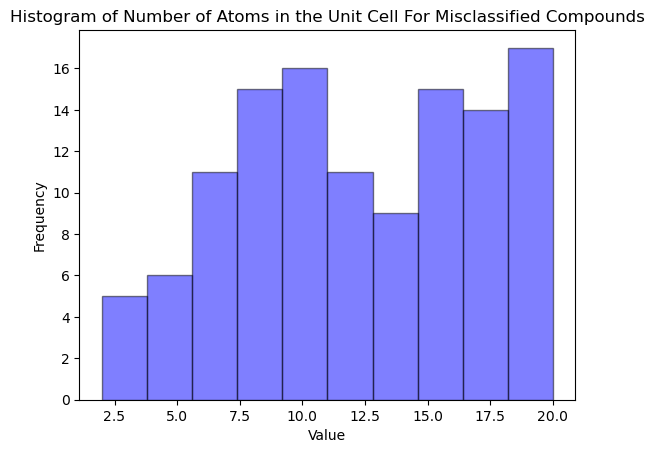

In [125]:
#first, let's get the number of elements in each of the crystals
num_elements = [len(ast.literal_eval(alist)) for alist in df_misclassfified['atomic_numbers']]

# Create a histogram
plt.hist(num_elements, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Number of Atoms in the Unit Cell For Misclassified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [127]:
np.mean(num_elements)

12.394957983193278

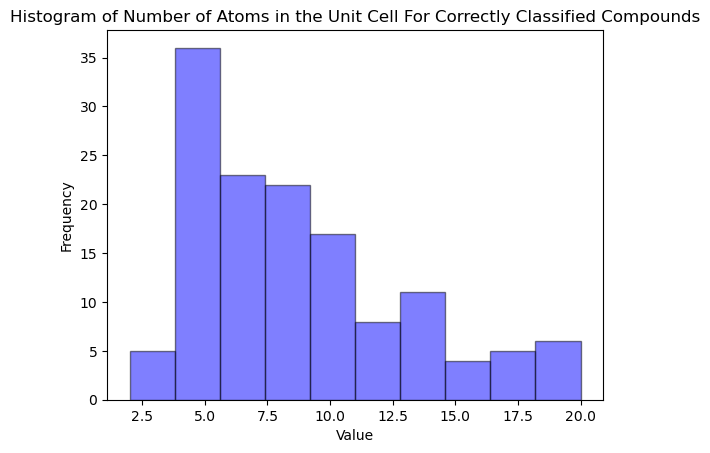

In [128]:
#first, let's get the number of elements in each of the crystals
num_elements = [len(ast.literal_eval(alist)) for alist in df_correctly_classified['atomic_numbers']]

# Create a histogram
plt.hist(num_elements, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Number of Atoms in the Unit Cell For Correctly Classified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [129]:
np.mean(num_elements)

8.583941605839415

Looks like the chance of getting a correct prediction drops off pretty steeply when the unit cell gets too big (though we're only limiting ourselves to 20 atom large unit cells here). I guess we could limit ourselves to compounds smaller than 10? Idk this seeems less valid than what we're doing on the alkaline earths. 

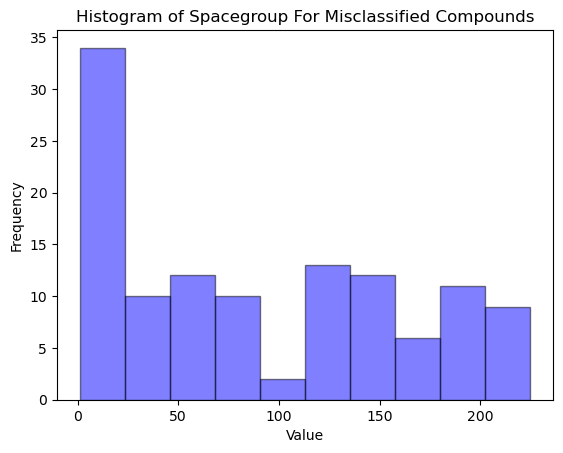

In [135]:
#first, let's get the number of elements in each of the crystals
space_groups = [float(number) for number in df_misclassfified['spacegroup.number']]

# Create a histogram
plt.hist(space_groups, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Spacegroup For Misclassified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [136]:
np.mean(space_groups)

91.0

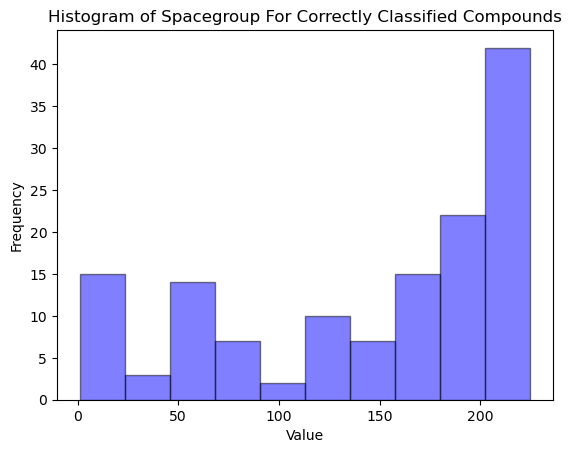

In [133]:
#first, let's get the number of elements in each of the crystals
space_groups = [float(number) for number in df_correctly_classified['spacegroup.number']]

# Create a histogram
plt.hist(space_groups, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Spacegroup For Correctly Classified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [134]:
np.mean(space_groups)

147.26277372262774

The space group results are awesomely interpretable! The model does better on more symmetric crystals and worse on less symmetric ones. This makes sense! 

Unfortunately, we can't just kick out the less symmetric crystals, that would be kind of ridiculous. But this was a very satisfying result

Ok, so main takeaways in terms of whether we can be more restrictive in terms of the crystals we're using is that we should probably impose some filters on atomic composition, at least for now. This is fairly straightforward in terms of restricting the test data, but requires a bit more thought in regards to applying to the training data since it will reduce the amount of training data availible, potentially by a lot. This is potentially addressable by just finding more data though. 

In addition, we need to start thinking more carefully about our train-val-test sets, especially if we start manipulating constraints and filters based on results. These initial results were done off the test set, but we may need to come back and redo on the val set to preserve the integrety of the test. In fact, we may need to re-split or get some more data for a fresh test set to avoid any kind of accidental overfitting to the test data.

Now, let's figure out why each one got misclassified to figure out how we can do better! The first way a crystal structure could fail is if it's just invalid. So let's see what percentage of the generated crystal structures were invalid. 

In [139]:
#added by Tsach
from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)

from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}

In [144]:
class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)

In [146]:
def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name


In [147]:
def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None

    return crys_array_list, true_crystal_array_list

In [198]:
recon_file_path = get_file_paths('/home/gridsan/tmackey/hydra/singlerun/2023-11-08/dropout_input_layer_mp_20/', 'recon',"")

# def get_crystal_array_list(file_path, batch_idx=0):
file_path = recon_file_path

crys_array_list, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=0)

In [195]:
# Add a new column for the comparison result in the subset
indices = list(df_subset['correctly_classified'] == False)
int_indices = [i for i, x in enumerate(indices) if x]

In [199]:
#we only want the misclassified ones 
crys_array_list = [crys_array_list[indice] for indice in int_indices]

In [201]:
pred_crys = []
counter = 0 
for x in crys_array_list: 
    pred_crys.append(Crystal(x))

In [211]:
pred_crys[2].structure

Structure Summary
Lattice
    abc : 3.285897970199584 6.386678695678712 6.777977466583252
 angles : 112.03535461425781 96.25308227539062 90.2225341796875
 volume : 130.91290482620786
      A : 3.2663484551566206 0.0 -0.35790115962051017
      B : -0.28750502555451174 5.913162653108792 -2.396145458856084
      C : 0.0 0.0 6.777977466583252
    pbc : True True True
PeriodicSite: Na (0.7929, 3.347, -0.1842) [0.2926, 0.5661, 0.1884]
PeriodicSite: Ti (0.907, 0.371, 4.364) [0.2832, 0.06274, 0.6811]
PeriodicSite: V (2.403, 3.291, 2.995) [0.7847, 0.5566, 0.6801]
PeriodicSite: S (2.583, 1.888, 4.957) [0.8188, 0.3192, 0.8874]
PeriodicSite: S (0.7163, 1.695, 2.388) [0.2445, 0.2866, 0.4665]
PeriodicSite: S (0.8616, 4.885, 3.988) [0.3365, 0.8261, 0.8982]
PeriodicSite: S (2.283, 4.711, 1.104) [0.7691, 0.7968, 0.4851]

In [202]:
true_crystal_array_list = [true_crystal_array_list[indice] for indice in int_indices]
gt_crys = []
counter = 0 

for x in true_crystal_array_list: 
    gt_crys.append(Crystal(x))

In [204]:
len(gt_crys)

119

In [205]:
#first thing to look into: how many of the predictions are actually valid
list_of_results = []
for crystal in pred_crys: 
    list_of_results.append(crystal.valid)

In [206]:
np.mean(list_of_results)

0.8067226890756303

Ok, so apparently only 80% are valid. This is a little sus given previous experience, but we did feed it the stoich so that probably helped a lot. That means that the difference must be in the structure

In [214]:
class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                if rms_dist is None: 
                    print(pred.structure)
                    print(gt.structure)
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()

In [215]:
rec_evaluator = RecEval(pred_crys, gt_crys)
recon_metrics = rec_evaluator.get_metrics()

[True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, False, True, True, False, True, False, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, False, False, True, False, True, True, True, True, True, True, True, False, False, False, True, True, True, True, True, True, False, True, True, True, False, True, True, True, True, False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, False, False, True, False, True, True, False, False, False, True, True, True, True, True, True, True, True]


 11%|█         | 13/119 [00:00<00:00, 109.73it/s]

Full Formula (Ga4 Te4)
Reduced Formula: GaTe
abc   :   4.270289   4.328177  14.716544
angles:  88.980713  90.253006  91.189255
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ga    0.814028  0.355547  0.627193
  1  Ga    0.316187  0.846424  0.379747
  2  Ga    0.306003  0.858792  0.877039
  3  Ga    0.808737  0.352355  0.12672
  4  Te    0.810521  0.858584  0.504079
  5  Te    0.804625  0.852901  0.002219
  6  Te    0.30636   0.355611  0.751888
  7  Te    0.312169  0.352835  0.253019
Full Formula (Ga4 Te4)
Reduced Formula: GaTe
abc   :   4.134600   4.134600  18.425570
angles:  90.000000  90.000000 120.000008
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ga    0.666667  0.333333  0.817041
  1  Ga    0.333333  0.666667  0.317041
  2  Ga    0.333333  0.666667  0.182959
  3  Ga    0.666667  0.333333  0.682959
  4  

 29%|██▉       | 35/119 [00:00<00:00, 100.65it/s]

Full Formula (Eu4 Al8 Ge4)
Reduced Formula: EuAl2Ge
abc   :   4.405741   6.938111  14.345037
angles:  95.755615  98.445580  88.885262
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Eu    0.300547  0.613715  0.735081
  1  Eu    0.432008  0.280878  0.990198
  2  Eu    0.540234  0.815382  0.178487
  3  Eu    0.144064  0.536835  0.432045
  4  Al    0.895729  0.632575  0.942634
  5  Al    0.039853  0.212418  0.200171
  6  Al    0.198526  0.063147  0.522701
  7  Al    0.846332  0.961959  0.837888
  8  Al    0.743163  0.876071  0.612783
  9  Al    0.630239  0.144147  0.384105
 10  Al    0.730791  0.298225  0.597552
 11  Al    0.290755  0.114667  0.721736
 12  Ge    0.122525  0.941548  0.333656
 13  Ge    0.396814  0.829388  0.953707
 14  Ge    0.842     0.328009  0.810872
 15  Ge    0.560665  0.403339  0.253367
Full Formula (Eu4 Al8 Ge4)
Reduced Formula: EuAl2Ge
abc   :   4.283127   7.246503  11.243032
a

...

Full Formula (Si2 C4 N8)
Reduced Formula: Si(CN2)2
abc   :   5.096716   5.802810   6.510518
angles:  87.484657  81.213638  87.906715
pbc   :       True       True       True
Sites (14)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Si    0.40938   0.121128  0.216266
  1  Si    0.806296  0.436847  0.635216
  2  C     0.242968  0.525548  0.75965
  3  C     0.130588  0.500231  0.303062
  4  C     0.093773  0.065992  0.554814
  5  C     0.973057  0.037142  0.082972
  6  N     0.904771  0.552061  0.391768
  7  N     0.994635  0.554185  0.803817
  8  N     0.306167  0.004405  0.467303
  9  N     0.221845  0.010538  0.041205
 10  N     0.344986  0.424004  0.221337
 11  N     0.863738  0.147132  0.630864
 12  N     0.48284   0.49577   0.721085
 13  N     0.733112  0.045969  0.14185
Full Formula (Si2 C4 N8)
Reduced Formula: Si(CN2)2
abc   :   6.684378   6.684378   6.684378
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sit

 92%|█████████▏| 109/119 [00:01<00:00, 118.19it/s]

Full Formula (Sr1 Eu1 Co2 O6)
Reduced Formula: SrEu(CoO3)2
abc   :   3.697403   3.734561  10.374268
angles:  86.908455  87.235947  82.775261
pbc   :       True       True       True
Sites (10)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Sr    0.619703  0.037884  0.260768
  1  Eu    0.55529   0.904939  0.727537
  2  Co    0.048862  0.395092  0.945343
  3  Co    0.105336  0.374982  0.494511
  4  O     0.100133  0.56168   0.645658
  5  O     0.136626  0.601253  0.342147
  6  O     0.05453   0.332758  0.111425
  7  O     0.048832  0.907539  0.881896
  8  O     0.639355  0.176355  0.499591
  9  O     0.563712  0.394269  0.876602
Full Formula (Sr1 Eu1 Co2 O6)
Reduced Formula: SrEu(CoO3)2
abc   :   3.788584   3.788584   7.676178
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (10)
  #  SP      a    b         c
---  ----  ---  ---  --------
  0  Sr    0    0    0.5
  1  Eu    0    0    0
  2  Co    0.5  0.5  0.252

100%|██████████| 119/119 [00:01<00:00, 113.50it/s]

Full Formula (H4 Pb4 Cl4 O4)
Reduced Formula: HPbClO
abc   :   3.914639   6.423855  10.501866
angles:  89.824303  90.220886  90.349335
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  H     0.288741  0.341824  0.027699
  1  H     0.794185  0.549794  0.248085
  2  H     0.785362  0.117592  0.247091
  3  H     0.280236  0.160716  0.753974
  4  Pb    0.79169   0.026746  0.992813
  5  Pb    0.282291  0.77477   0.294578
  6  Pb    0.789598  0.22649   0.564594
  7  Pb    0.297782  0.754783  0.732587
  8  Cl    0.295316  0.281332  0.355321
  9  Cl    0.287506  0.680119  0.040423
 10  Cl    0.78923   0.406565  0.799928
 11  Cl    0.784193  0.790709  0.502496
 12  O     0.790964  0.919553  0.815934
 13  O     0.289797  0.187168  0.009161
 14  O     0.780724  0.97366   0.207471
 15  O     0.283806  0.107172  0.664469
Full Formula (H4 Pb4 Cl4 O4)
Reduced Formula: HPbClO
abc   :   4.069687   7.185355   9.957517

In [209]:
recon_metrics

{'match_rate': 0.13445378151260504,
 'rms_dist': 0.09438773780407993,
 'diff_dist': None,
 'rmsd_values': array([None, None, None, None, None, 0.32461618937675685, None, None,
        None, None, None, None, 0.03113012244576284, None, None, None,
        0.029466852081423783, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, 0.010359323160226478,
        None, None, None, None, None, None, None, None, None,
        0.17127295872589407, None, None, None, None, None, None, None,
        None, None, None, 0.01399317643063499, None, None, None, None,
        None, None, None, None, 0.045470572418107466, 0.009091251777578016,
        0.41130352571349504, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None,
        0.013252947601903983, 0.02367450236321188, None, None, None, None,
        None, None, None, 0.010350051406569713, None, None, None, None,
        0.041141999299418655, None, None, 0

From this analysis, I think it's now abundantly clear that the biggest limitation of the stoich-informed dropout model is the inability to predict low-symmetry groups (very understandable tbh) and the more we can push it towards that goal the better. It might be worth trying to implement a space-group predictor either with the native property prediction method or with an external tool that has been developed specifically for this purpose. This is a whole additional branch of optimization and experiments but it could lead to good results I think.